# Values to compare
### Target: 
 - overall_survival_months

### Predictors:
 - age_at_diagnosis
 - cancer_type_detailed
 - chemotherapy
 - tumor_stage
 - tumor_size
 - type_of_breast_surgery
 - death_from_cancer

#### Definitions
 -  Invasive Ductal Carcinoma (IDC): IDC (approx. 80% of cases) starts in milk ducts and forms lumps
 -  Invasive Lobular Carcinoma (ILC): ILC (10-15% of cases) starts in milk-producing lobules, often growing in single-file lines that make it harder to detect on mammograms. 

In [2]:
import pandas as pd
import sklearn as skl
import sys
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [3]:
skl.__version__

'1.8.0'

# EDA

In [4]:
cancer_data = pd.read_csv("METABRIC_RNA_Mutation.csv")

C:\Users\dimar\AppData\Local\Temp\ipykernel_3000\3419895987.py:1: DtypeWarning: Columns (0: rasgef1b_mut, 1: hras_mut, 2: smarcb1_mut, 3: siah1_mut) have mixed types. Specify dtype option on import or set low_memory=False.
  cancer_data = pd.read_csv("METABRIC_RNA_Mutation.csv")


In [5]:
cancer_data.head()

,patient_id,age_at_diagnosis,type_of_breast_surgery,cancer_type,cancer_type_detailed,cellularity,chemotherapy,pam50_+_claudin-low_subtype,cohort,er_status_measured_by_ihc,...,mtap_mut,ppp2cb_mut,smarcd1_mut,nras_mut,ndfip1_mut,hras_mut,prps2_mut,smarcb1_mut,stmn2_mut,siah1_mut
0,0,75.65,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,NaN,0,claudin-low,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
1,2,43.19,BREAST CONSERVING,Breast Cancer,Breast Invasive Ductal Carcinoma,High,0,LumA,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
2,5,48.87,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,High,1,LumB,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
3,6,47.68,MASTECTOMY,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,Moderate,1,LumB,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
4,8,76.97,MASTECTOMY,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,High,1,LumB,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0


In [6]:
# Chosen variables
predictors = cancer_data[['age_at_diagnosis', 'cancer_type_detailed', 'chemotherapy', 'tumor_stage', 'tumor_size', 'type_of_breast_surgery', 'death_from_cancer', 'overall_survival_months']]

# Summary Statistics

In [7]:
#Qualitative predictors: cancer_type_detailed, 'type_of_breast_surgery', 'death_from_cancer'
predictors_description = predictors.describe()
print(predictors_description)

       age_at_diagnosis  chemotherapy  tumor_stage   tumor_size  \
count       1904.000000   1904.000000  1403.000000  1884.000000   
mean          61.087054      0.207983     1.750535    26.238726   
std           12.978711      0.405971     0.628999    15.160976   
min           21.930000      0.000000     0.000000     1.000000   
25%           51.375000      0.000000     1.000000    17.000000   
50%           61.770000      0.000000     2.000000    23.000000   
75%           70.592500      0.000000     2.000000    30.000000   
max           96.290000      1.000000     4.000000   182.000000   

       overall_survival_months  
count              1904.000000  
mean                125.121324  
std                  76.334148  
min                   0.000000  
25%                  60.825000  
50%                 115.616667  
75%                 184.716667  
max                 355.200000  


In [8]:
missing_predictors = predictors.isna().sum()
missing_predictors

age_at_diagnosis             0
cancer_type_detailed        15
chemotherapy                 0
tumor_stage                501
tumor_size                  20
type_of_breast_surgery      22
death_from_cancer            1
overall_survival_months      0
dtype: int64

# Visualizations

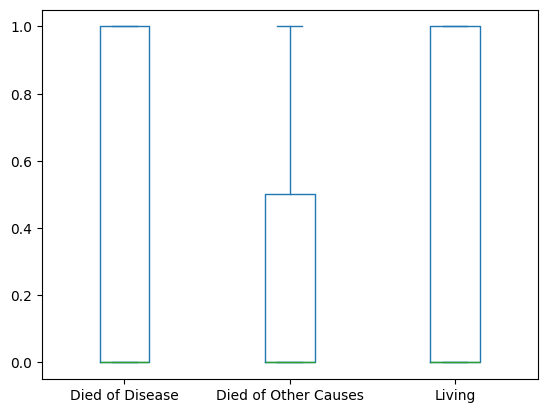

In [9]:
pd.crosstab(
    predictors["overall_survival_months"],
    predictors["death_from_cancer"],
    normalize="index"
).plot(kind="box", stacked=True)

plt.show()

# Correlations

In [10]:
# 'age_at_diagnosis', 'cancer_type_detailed', 'chemotherapy', 'tumor_stage', 'tumor_size', 'type_of_breast_surgery', 'death_from_cancer'

#survival_death_correlation = predictors['overall_survival_months'].corr(predictors['death_from_cancer'], method='spearman')
survival_age_correlation = predictors['overall_survival_months'].corr(predictors['age_at_diagnosis'], method='spearman')
survival_chemotherapy_correlation = predictors['overall_survival_months'].corr(predictors['chemotherapy'], method='spearman')
survival_tumor_stage_correlation = predictors['overall_survival_months'].corr(predictors['tumor_stage'], method='spearman')
survival_tumor_size_correlation = predictors['overall_survival_months'].corr(predictors['tumor_size'], method='spearman')

#print(survival_death_correlation)
print("survival_age_correlation: " + str(survival_age_correlation))
print("survival_chemotherapy_correlation: " + str(survival_chemotherapy_correlation))
print("survival_tumor_stage_correlation: " + str(survival_tumor_stage_correlation))
print("survival_tumor_size_correlation: " + str(survival_tumor_size_correlation))

survival_age_correlation: -0.14130924864941208
survival_chemotherapy_correlation: -0.16695575109956204
survival_tumor_stage_correlation: -0.2804146615795238
survival_tumor_size_correlation: -0.22806547183981116


# Group work split
# Fenny: Section 3
# Jessica: section 2
# Chase: Section 6 and 7
# Harris: Section 4 and 5

In [11]:
print(type(survival_age_correlation))
print("survival_age_correlation:", survival_age_correlation)
print("survival_age_correlation:" + str(survival_age_correlation))
#print("survival_age_correlation:" + survival_age_correlation) doesn't work? Random python syntax interest; Plus symbol is only for string concatenation

<class 'numpy.float64'>
survival_age_correlation: -0.14130924864941208
survival_age_correlation:-0.14130924864941208


# 4.6 Transformations (EDA to find where known methods could be used)

In [12]:
# General overview of two variables of interest
death_from_cancer_check = predictors[['overall_survival_months','death_from_cancer']]
death_from_cancer_check.head(10)

,overall_survival_months,death_from_cancer
0,140.500000,Living
1,84.633333,Living
2,163.700000,Died of Disease
3,164.933333,Living
4,41.366667,Died of Disease
5,7.800000,Died of Disease
6,164.333333,Living
7,99.533333,Died of Other Causes
8,36.566667,Died of Other Causes
9,36.266667,Died of Disease


In [13]:
death_from_cancer_check.groupby("death_from_cancer")["overall_survival_months"].describe()

,count,mean,std,min,25%,50%,75%,max
death_from_cancer,,,,,,,,
Died of Disease,622.0,77.225456,59.648339,0.1,33.916667,56.716667,106.341667,335.733333
Died of Other Causes,480.0,129.460903,70.267482,2.3,76.175000,122.433333,179.508333,355.200000
Living,801.0,159.551228,71.691593,0.0,108.066667,158.033333,216.733333,337.033333


### Initial trend
- Those who survive longer, more often are living. But longest life is similar in each category.

In [ ]:
# Break up `predictor` variable
features = ["age_at_diagnosis","cancer_type_detailed","chemotherapy",
            "tumor_stage","tumor_size","type_of_breast_surgery","death_from_cancer"]
target = "overall_survival_months"

X = predictors[[target] + features].copy()
miss = X.isna().mean().sort_values(ascending=False)
miss

tumor_stage                0.263130
type_of_breast_surgery     0.011555
tumor_size                 0.010504
cancer_type_detailed       0.007878
death_from_cancer          0.000525
chemotherapy               0.000000
overall_survival_months    0.000000
age_at_diagnosis           0.000000
dtype: float64

### Verify na and missingness 
 - tumor_stage has 26% missing
 - all other predictors are less than 2%
> High missingness encourages:
> - Simpler encoding (one hot for binary; has no does not have)
> - Imputation methods (distribution preserving random imputation)

skew: 0.3841125048718981


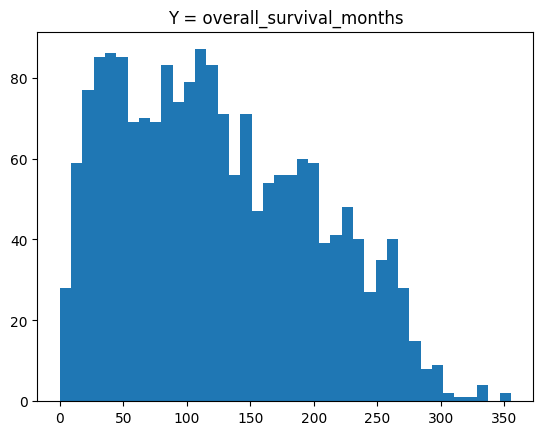

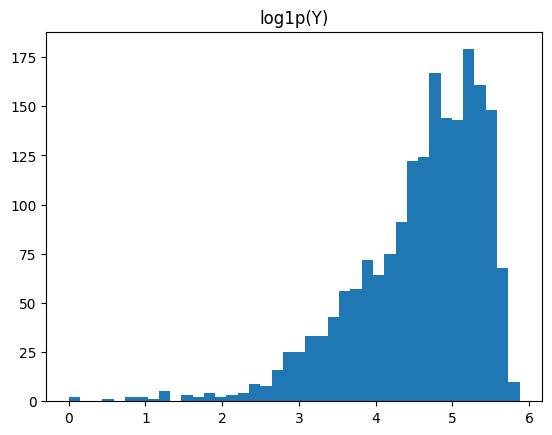

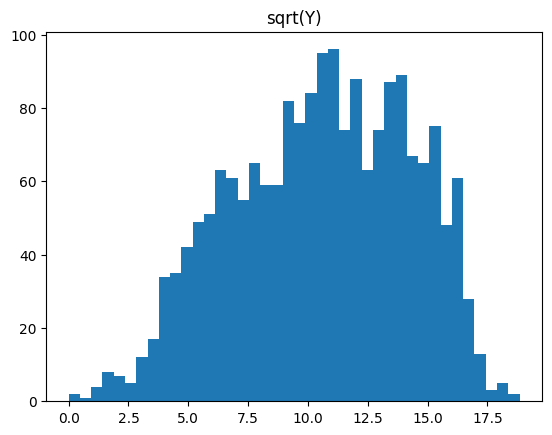

In [17]:
# Drop NA's
Y = X[target].dropna()

# Skew value
print("skew:", Y.skew())

# Distribution and log distribution
plt.hist(Y, bins=40); plt.title("Y = overall_survival_months"); plt.show()
plt.hist(np.log1p(Y), bins=40); plt.title("log1p(Y)"); plt.show()
plt.hist(np.sqrt(Y), bins=40); plt.title("sqrt(Y)"); plt.show()

In [ ]:
# log-scale interpretation

# Anchor the log-scale interpretation to the observed maximum survival time
max_months = Y.max()
max_log = np.log1p(max_months)

# Create representative points along the log-transformed scale
log_vals = np.linspace(0, max_log, 6)
months = np.expm1(log_vals)

# Map log-scale values back to approximate survival months for interpretability
pd.DataFrame({
    "log1p_value": log_vals.round(2),
    "approx_survival_months": months.round(1)
})

,log1p_value,approx_survival_months
0,0.00,0.0
1,1.18,2.2
2,2.35,9.5
3,3.53,33.0
4,4.70,109.0
5,5.88,355.2


### Observation of histograms (**response transformation**)
- `overall_survival_months` is not extremely skewed (skew ~38), mild right tail ; x-axis
- `log1p` compresses meaningful differences, stronger left tail ; y-axis ()
- `sqrt` is likely mild enough to benefit distribution here.
> Could potentially make more normally distributed. But not terrible.

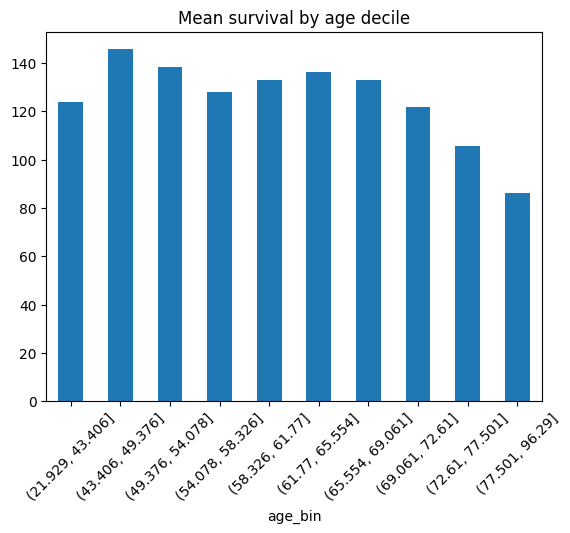

In [ ]:
# Examine the shape of the age–survival relationship without fitting a model
tmp = X.dropna(subset=["age_at_diagnosis", "overall_survival_months"]).copy()
tmp["age_bin"] = pd.qcut(tmp["age_at_diagnosis"], q=10, duplicates="drop")

# Compute mean survival within age deciles to assess monotonicity and curvature
age_curve = tmp.groupby("age_bin")["overall_survival_months"].mean()
age_curve.plot(kind="bar", rot=45)

# Visual check to determine whether a linear age term is a reasonable baseline
plt.title("Mean survival by age decile")
plt.show()

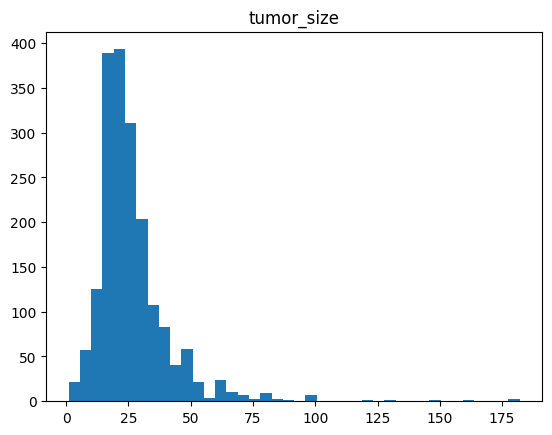

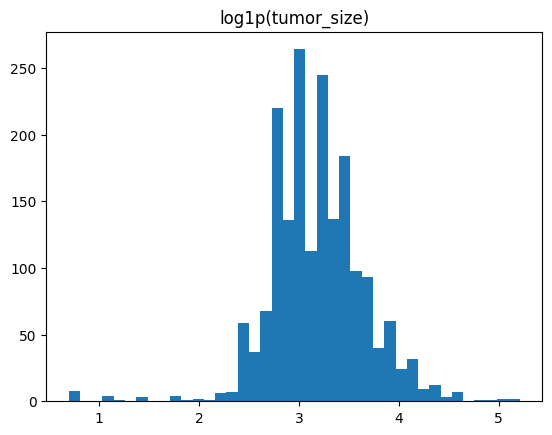

In [ ]:
# Tumor size distribution

# Drop NAs from tumor_size
x = X["tumor_size"].dropna()

# Distributions
plt.hist(x, bins=40); plt.title("tumor_size"); plt.show()
plt.hist(np.log1p(x), bins=40); plt.title("log1p(tumor_size)"); plt.show()

In [ ]:
# Non-monotonicity check: median survival by stage
tmp = X.dropna(subset=["tumor_stage", "overall_survival_months"])
print(tmp.groupby("tumor_stage")["overall_survival_months"].median().sort_index())

tumor_stage
0.0     95.300000
1.0    152.066667
2.0    108.333333
3.0     54.100000
4.0     48.533333
Name: overall_survival_months, dtype: float64


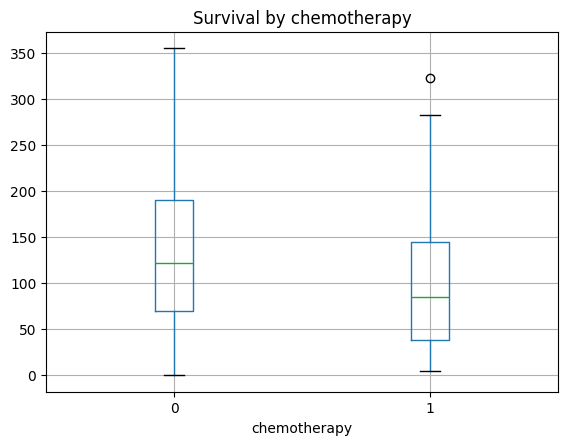

In [ ]:
# Chemotherapy and overall survival months
tmp = X.dropna(subset=["chemotherapy","overall_survival_months"])
tmp.boxplot(column="overall_survival_months", by="chemotherapy")
plt.title("Survival by chemotherapy"); plt.suptitle("")
plt.show()

In [ ]:
# Average suvival months in each tumor stage

# Missingness indicator
X["tumor_stage_missing"] = X["tumor_stage"].isna().astype(int)

# Count missing vs observed values (26% missing expected)
missing_counts = X["tumor_stage"].isna().value_counts()
print("Tumor stage missingness counts:")
print(missing_counts, "\n")

# Proportion missing (useful for reporting and thresholds)
missing_rate = X["tumor_stage"].isna().mean()
print(f"Tumor stage missing rate: {missing_rate}", "\n")

stage_summary = X.groupby("tumor_stage")[target].median().sort_index()
print(stage_summary, "\n")

# Distribution of observed tumor_stage values
print("Observed tumor_stage distribution:")
stage_dist = (X["tumor_stage"].value_counts(dropna=True, normalize=True))
print(stage_dist)

Tumor stage missingness counts:
tumor_stage
False    1403
True      501
Name: count, dtype: int64 

Tumor stage missing rate: 0.26313025210084034 

tumor_stage
0.0     95.300000
1.0    152.066667
2.0    108.333333
3.0     54.100000
4.0     48.533333
Name: overall_survival_months, dtype: float64 

Observed tumor_stage distribution:
tumor_stage
2.0    0.570207
1.0    0.338560
3.0    0.081967
4.0    0.006415
0.0    0.002851
Name: proportion, dtype: float64


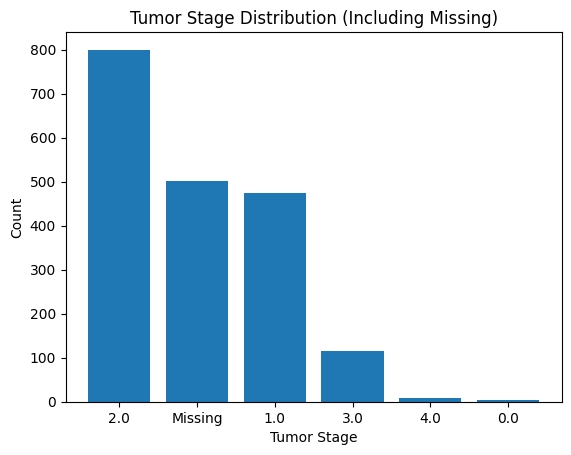

In [ ]:
stage_counts = X["tumor_stage"].fillna("Missing").value_counts()

plt.figure()
plt.bar(stage_counts.index.astype(str), stage_counts.values)
plt.title("Tumor Stage Distribution (Including Missing)")
plt.xlabel("Tumor Stage")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

In [ ]:
# Quantity of cancer types (cardinality test)
X["cancer_type_detailed"].value_counts(dropna=True).head(15)

cancer_type_detailed
Breast Invasive Ductal Carcinoma             1500
Breast Mixed Ductal and Lobular Carcinoma     207
Breast Invasive Lobular Carcinoma             142
Breast Invasive Mixed Mucinous Carcinoma       22
Breast                                         17
Metaplastic Breast Cancer                       1
Name: count, dtype: int64

### Predictor variables
- age_at_diagnosis ; Not perfectly linear, survival decreases with age
- tumor_size ; strong right skew, few large values. Log stabilizes, preserves order, compresses extremes
- tumor_stage ; substantial missingness, non-ordinal to avoid imposing a structure that it can't support
- chemotherapy ; chemo group has lower median survival, sicker / later stage patient are more likely to have chemo (not causal interpretation)
- type_of_breast_surgery ; low missingness, one-hot encoding, i.e. "was this surgery type performed"
- cancer_type_detailed ; high cardinality variable, with rare levels. One hot encoding and if needed, rare-category grouping for stability and reduce overfit
- death_from_cancer ; Determined after follow up, explorative. Likely extremely high correlation due to life and death binary.

### TLDR;
- Y: raw (primary), log(Y) (sensitivity)
- Age: linear (primary), smooth/nonlinear (optional)
- Tumor size: raw or log1p
- Stage: categorical only
- Chemotherapy: binary, no transform
- Cancer type / surgery: categorical with rare-level grouping

In [ ]:
# Exploratory
pd.crosstab(X["tumor_stage"], X["death_from_cancer"], normalize="index")

death_from_cancer,Died of Disease,Died of Other Causes,Living
tumor_stage,,,
0.0,0.000000,0.250000,0.750000
1.0,0.227848,0.223629,0.548523
2.0,0.357500,0.245000,0.397500
3.0,0.582609,0.165217,0.252174
4.0,0.888889,0.000000,0.111111


- Linear decline for `living` status as tumor_stage gets more severe
- Compounding increase in `Died of Disease` after initial tumor_stage development
- `Died of Other Causes` has a decrease as well, until it hits 0% for stage 4

# 4.7 Model validation strategy

 - Split data into Train (80%), Validate (10%), Test (10%):

 - For each candidate specification from Section 6:
     - Run K-fold CV on Train
     - Record mean RMSE/MAE (and R²)
 - Select simplest spec within ~1 SD of best RMSE
 - Fit final model on Train with selected spec
 - Evaluate once on Test with RMSE/MAE/R²